In [1]:
## IMPORTS 
import os
import sys 
LOCSCALE_2_SCRIPTS_PATH = "/home/abharadwaj1/papers/publications/2025_LocScale-2.0"
PLOT_DATA_STORE_PATH = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/data"
sys.path.append(LOCSCALE_2_SCRIPTS_PATH)
from scripts.utils.plot_utils import *

import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import seaborn as sns
import pickle
import pandas as pd
from scripts.utils.plot_utils import pretty_plot_radial_profile, temporary_rcparams, configure_plot_scaling
from scripts.utils.general import setup_environment, create_folders_if_they_do_not_exist
from locscale.include.emmer.ndimage.map_utils import load_map, save_as_mrc
from locscale.include.emmer.ndimage.profile_tools import compute_radial_profile, estimate_bfactor_standard, frequency_array
random.seed(42)
np.random.seed(42)

In [2]:
parent_folder = os.path.join(PLOT_DATA_STORE_PATH, "rebuttal", "bfactor_correlation")

prediction_map_path = os.path.join(parent_folder, "emd_0282_emmernet_output_mean.mrc")
hybrid_model_map_path = os.path.join(parent_folder, "emd_0282_hybrid_model_map_refined_version_C.mrc")
mask_path = os.path.join(parent_folder, "emd_0282_FDR_confidence_final.map")

output_plot_path = os.path.join(parent_folder, "bfactor_correlation_learned_v_refined.pdf")

n_samples = 200

In [3]:
predicted_map, apix = load_map(prediction_map_path)
hybrid_model_map, _ = load_map(hybrid_model_map_path)
confidence_map, _ = load_map(mask_path)


In [4]:
mask_binarised = confidence_map > 0.99
all_voxels_in_mask = np.array(np.where(mask_binarised)).T.tolist()

sampled_voxels = random.sample(all_voxels_in_mask, n_samples)
window_size_angstrom = 25
window_size = int(window_size_angstrom / apix)

In [5]:
from locscale.include.emmer.ndimage.map_utils import extract_window

local_bfactor_list_predicted = []
local_bfactor_list_hybrid_model = []
bfactor_data = []
for center in sampled_voxels:
    predicted_window = extract_window(predicted_map, center, window_size)
    hybrid_model_window = extract_window(hybrid_model_map, center, window_size)
    
    rp_predicted = compute_radial_profile(predicted_window)
    rp_hybrid_model = compute_radial_profile(hybrid_model_window)
    freq = frequency_array(rp_hybrid_model, apix=apix)
    
    bfactor_predicted = estimate_bfactor_standard(
        freq=freq, 
        amplitude=rp_predicted, 
        wilson_cutoff=10, 
        fsc_cutoff=2*apix+1,
        standard_notation=True
    )

    bfactor_hybrid_model = estimate_bfactor_standard(
        freq=freq, 
        amplitude=rp_hybrid_model, 
        wilson_cutoff=10, 
        fsc_cutoff=2*apix+1,
        standard_notation=True
    )

    
    local_bfactor_list_predicted.append(bfactor_predicted)
    local_bfactor_list_hybrid_model.append(bfactor_hybrid_model)
    bfactor_data.append({
        "predicted_bfactor": bfactor_predicted,
        "hybrid_model_bfactor": bfactor_hybrid_model
    })
bfactor_df = pd.DataFrame(bfactor_data)

pearson_corr = bfactor_df["predicted_bfactor"].corr(bfactor_df["hybrid_model_bfactor"])

print(f"Pearson correlation between learned b-factors and refined model b-factors: {pearson_corr:.3f}")

Pearson correlation between learned b-factors and refined model b-factors: 0.916


/tmp/ipykernel_17608/1333360546.py:26: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=6)
/tmp/ipykernel_17608/1333360546.py:27: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)


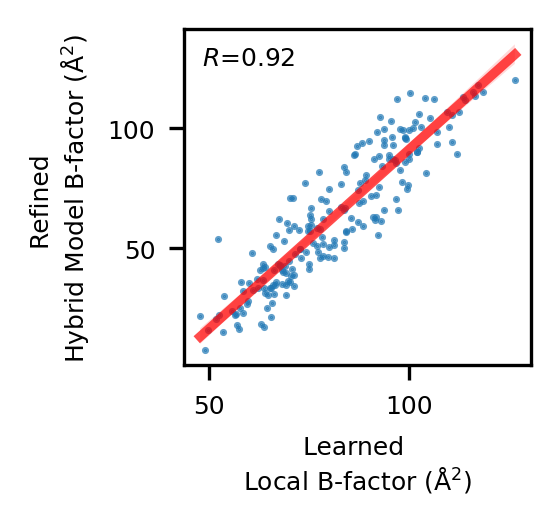

In [6]:
figsize_mm = (50, 50)
figsize_in = (figsize_mm[0]/25.4, figsize_mm[1]/25.4)

rc_params_new = configure_plot_scaling(figsize_mm=figsize_mm)
rc_params_new['figure.dpi'] = 300
with temporary_rcparams(rc_params_new):
    fig, ax = plt.subplots(figsize=figsize_in)
        
    sns.regplot(
        data=bfactor_df, 
        x="predicted_bfactor", 
        y="hybrid_model_bfactor",
        scatter_kws={"s": 0.5, "alpha":0.7},
        line_kws={"color":"red", "alpha":0.7},
        ax=ax
    )
    correlation_text = r'$R$={}'.format(f"{pearson_corr:.2f}")
    ax.text(
        0.05, 0.95, correlation_text, 
        transform=ax.transAxes, 
        fontsize=6,
        verticalalignment='top'
    )
    # aspect ratio 1:1
    ax.set_aspect(0.6, adjustable='box')
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=6)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)
    ax.set_xlabel("Learned \nLocal B-factor (Å$^2$)", fontsize=6)    
    ax.set_ylabel("Refined \nHybrid Model B-factor (Å$^2$)", fontsize=6)
    fig.tight_layout()
    fig.savefig(output_plot_path)

In [7]:
# from tqdm import tqdm 

# bfactor_map_predicted = np.zeros_like(predicted_map)
# bfactor_map_hybrid_model = np.zeros_like(predicted_map)

# for voxel in tqdm(all_voxels_in_mask):
#     try:
#         predicted_window = extract_window(predicted_map, voxel, window_size)
#         hybrid_model_window = extract_window(hybrid_model_map, voxel, window_size)
        
#         rp_predicted = compute_radial_profile(predicted_window)
#         rp_hybrid_model = compute_radial_profile(hybrid_model_window)
#         freq = frequency_array(rp_hybrid_model, apix=apix)
        
#         bfactor_predicted = estimate_bfactor_standard(
#             freq=freq, 
#             amplitude=rp_predicted, 
#             wilson_cutoff=10, 
#             fsc_cutoff=2*apix+1,
#             standard_notation=True
#         )

#         bfactor_hybrid_model = estimate_bfactor_standard(
#             freq=freq, 
#             amplitude=rp_hybrid_model, 
#             wilson_cutoff=10, 
#             fsc_cutoff=2*apix+1,
#             standard_notation=True
#         )
        
#         bfactor_map_predicted[tuple(voxel)] = bfactor_predicted
#         bfactor_map_hybrid_model[tuple(voxel)] = bfactor_hybrid_model
#     except Exception as e:
#         continue

# bfactor_map_predicted_path = os.path.join(parent_folder, "local_bfactor_map_predicted_emmernet.mrc")
# save_as_mrc(bfactor_map_predicted, bfactor_map_predicted_path, apix)
# bfactor_map_hybrid_model_path = os.path.join(parent_folder, "local_bfactor_map_hybrid_model_emmernet.mrc")
# save_as_mrc(bfactor_map_hybrid_model, bfactor_map_hybrid_model_path, apix)

# print(f"Saved local b-factor maps at: {bfactor_map_predicted_path} and {bfactor_map_hybrid_model_path}")

In [8]:
# get a distribution of pearson correlations for many maps 
# 0282_6huo  0560_6nzu   20220_6oxl  3545_5mqf  4531_6qdw  4997_6rtc  8702_5vkq
# 0311_6hz5  10365_6t23  20226_6p07  4141_5m1s  4571_6qk7  7127_6bpq  9610_6adq
emdb_id_list = [
    "0282", "0311", "0560", "10365", "20220", "20226", "3545", "4141", "4531", "4571", "4997", "7127", "8702", "9610"
]
hybrid_model_maps_parent_folder = "/home/abharadwaj1/papers/elife_paper/figure_information/data/hybrid_model_maps_version_C"
predictions_parent_folder = "/home/abharadwaj1/papers/elife_paper/figure_information/outputs/feature_enhance_test_maps_hybrid_60k"
hybrid_model_map_paths_emdb = {
    emdb: os.path.join(hybrid_model_maps_parent_folder, f"emd_{emdb}_hybrid_model_map_refined_version_C.mrc")
    for emdb in emdb_id_list if os.path.exists(os.path.join(hybrid_model_maps_parent_folder, f"emd_{emdb}_hybrid_model_map_refined_version_C.mrc"))
}
predicted_model_map_paths_emdb = {}
for emdb_pdb in os.listdir(predictions_parent_folder):
    emdb_id = emdb_pdb.split("_")[0]
    prediction_path_this_emdb = os.path.join(predictions_parent_folder, emdb_pdb, f"emd_{emdb_id}_emmernet_output_mean.mrc")
    if os.path.exists(prediction_path_this_emdb):
        predicted_model_map_paths_emdb[emdb_id] = prediction_path_this_emdb

confidence_map_parent_folder = "/home/abharadwaj1/papers/elife_paper/figure_information/data/confidence_masks"
confidence_map_paths_emdb = {
    emdb: os.path.join(confidence_map_parent_folder, f"emd_{emdb}_FDR_confidence_final.map")
    for emdb in emdb_id_list if os.path.exists(os.path.join(confidence_map_parent_folder, f"emd_{emdb}_FDR_confidence_final.map"))
}

common_emdb_ids = set(hybrid_model_map_paths_emdb.keys()).intersection(set(predicted_model_map_paths_emdb.keys())).intersection(set(confidence_map_paths_emdb.keys()))
print(f"Common EMD IDs found: {common_emdb_ids}")



Common EMD IDs found: {'20220', '0311', '10365', '20226', '4571', '4997', '3545', '7127', '0282', '8702', '9610'}


In [9]:
all_bfactor_correlation_data = []
for emdb in common_emdb_ids:
    print(f"Processing EMD-{emdb}...")
    prediction_map_path = predicted_model_map_paths_emdb[emdb]
    hybrid_model_map_path = hybrid_model_map_paths_emdb[emdb]
    mask_path = confidence_map_paths_emdb[emdb]
    
    predicted_map, apix = load_map(prediction_map_path)
    hybrid_model_map, _ = load_map(hybrid_model_map_path)
    confidence_map, _ = load_map(mask_path)


    mask_binarised = confidence_map > 0.99
    all_voxels_in_mask = np.array(np.where(mask_binarised)).T.tolist()

    sampled_voxels = random.sample(all_voxels_in_mask, n_samples)
    window_size_angstrom = 25
    window_size = int(window_size_angstrom / apix)

    local_bfactor_list_predicted = []
    local_bfactor_list_hybrid_model = []
    bfactor_data = []
    for center in sampled_voxels:
        predicted_window = extract_window(predicted_map, center, window_size)
        hybrid_model_window = extract_window(hybrid_model_map, center, window_size)
        try:
            rp_predicted = compute_radial_profile(predicted_window)
            rp_hybrid_model = compute_radial_profile(hybrid_model_window)
            freq = frequency_array(rp_hybrid_model, apix=apix)
            
            bfactor_predicted = estimate_bfactor_standard(
                freq=freq, 
                amplitude=rp_predicted, 
                wilson_cutoff=10, 
                fsc_cutoff=2*apix+1,
                standard_notation=True
            )

            bfactor_hybrid_model = estimate_bfactor_standard(
                freq=freq, 
                amplitude=rp_hybrid_model, 
                wilson_cutoff=10, 
                fsc_cutoff=2*apix+1,
                standard_notation=True
            )
        except Exception as e:
            continue
        
        local_bfactor_list_predicted.append(bfactor_predicted)
        local_bfactor_list_hybrid_model.append(bfactor_hybrid_model)
        bfactor_data.append({
            "predicted_bfactor": bfactor_predicted,
            "hybrid_model_bfactor": bfactor_hybrid_model
        })
    bfactor_df = pd.DataFrame(bfactor_data)

    pearson_corr = bfactor_df["predicted_bfactor"].corr(bfactor_df["hybrid_model_bfactor"])
    print(f"Pearson correlation between learned b-factors and refined model b-factors for EMD-{emdb}: {pearson_corr:.3f}")
    all_bfactor_correlation_data.append({
        "emdb_id": emdb,
        "pearson_correlation": pearson_corr
    })
    # save the bfactor df for this emdb as a csv
    bfactor_data_folder = os.path.join(parent_folder, "bfactor_correlation_data")
    create_folders_if_they_do_not_exist(bfactor_data_folder)
    bfactor_df_path = os.path.join(bfactor_data_folder, f"emd_{emdb}_bfactor_correlation_data.csv")
    bfactor_df.to_csv(bfactor_df_path, index=True)
all_bfactor_correlation_df = pd.DataFrame(all_bfactor_correlation_data)


Processing EMD-20220...
Pearson correlation between learned b-factors and refined model b-factors for EMD-20220: 0.795
Processing EMD-0311...
Pearson correlation between learned b-factors and refined model b-factors for EMD-0311: 0.552
Processing EMD-10365...
Pearson correlation between learned b-factors and refined model b-factors for EMD-10365: 0.821
Processing EMD-20226...
Pearson correlation between learned b-factors and refined model b-factors for EMD-20226: 0.742
Processing EMD-4571...
Pearson correlation between learned b-factors and refined model b-factors for EMD-4571: 0.888
Processing EMD-4997...
Pearson correlation between learned b-factors and refined model b-factors for EMD-4997: 0.611
Processing EMD-3545...
Pearson correlation between learned b-factors and refined model b-factors for EMD-3545: 0.458
Processing EMD-7127...
Pearson correlation between learned b-factors and refined model b-factors for EMD-7127: 0.793
Processing EMD-0282...
Pearson correlation between learned

In [10]:
# plot histogram of pearson correlations
figsize_mm = (40, 40)
figsize_in = (figsize_mm[0]/25.4, figsize_mm[1]/25.4)
rc_params_new = configure_plot_scaling(figsize_mm=figsize_mm)
rc_params_new['figure.dpi'] = 300
with temporary_rcparams(rc_params_new):
    fig, ax = plt.subplots(figsize=figsize_in)
        
    sns.histplot(
        data=all_bfactor_correlation_df, 
        x="pearson_correlation", 
        kde=True,
        ax=ax,
        stat="count"
    )
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    num_samples_text = f"N={len(all_bfactor_correlation_df)}"
    ax.text(
        0.3, 0.95, num_samples_text, 
        transform=ax.transAxes, 
        fontsize=6,
        verticalalignment='top',
        horizontalalignment='right'
    )
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=6)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)
    ax.set_xlabel("Pearson Correlations", fontsize=6)    
    ax.set_ylabel("Count", fontsize=6)
    fig.tight_layout()
    histogram_output_plot_path = os.path.join(parent_folder, "bfactor_correlation_histogram.pdf")
    fig.savefig(histogram_output_plot_path)

/tmp/ipykernel_17608/4038979773.py:26: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)
